In [1]:
# =========================
# 1. IMPORTS
# =========================
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV




In [3]:
# 2. LOAD DATA
# =========================
df = pd.read_csv("/Users/Pooja/Documents/capstone_projects/projects/cover_type.csv")

In [4]:
print("Duplicate rows:", df.duplicated().sum())
print(df.isnull().sum())

Duplicate rows: 0
Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Cover_Type                            0
Wilderness_Area                       0
Soil_Type                             0
dtype: int64


In [5]:
# =========================
# 3. BASIC EDA
# =========================
print("Shape:", df.shape)
print("\nInfo:")
print(df.info())




Shape: (145890, 13)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145890 entries, 0 to 145889
Data columns (total 13 columns):
 #   Column                              Non-Null Count   Dtype 
---  ------                              --------------   ----- 
 0   Elevation                           145890 non-null  int64 
 1   Aspect                              145890 non-null  int64 
 2   Slope                               145890 non-null  int64 
 3   Horizontal_Distance_To_Hydrology    145890 non-null  int64 
 4   Vertical_Distance_To_Hydrology      145890 non-null  int64 
 5   Horizontal_Distance_To_Roadways     145890 non-null  int64 
 6   Hillshade_9am                       145890 non-null  int64 
 7   Hillshade_Noon                      145890 non-null  int64 
 8   Hillshade_3pm                       145890 non-null  int64 
 9   Horizontal_Distance_To_Fire_Points  145890 non-null  int64 
 10  Cover_Type                          145890 non-null  object
 11  Wilderness_A

In [6]:
print("Wilderness_Area number of classes:", df["Wilderness_Area"].nunique())
print("Soil_Type number of classes:",df["Soil_Type"].nunique())
print("Cover_Type number of classes:",df["Cover_Type"].nunique())
# Target distribution
print("\nCover Type Distribution:")
print(df["Cover_Type"].value_counts())


Wilderness_Area number of classes: 4
Soil_Type number of classes: 39
Cover_Type number of classes: 7

Cover Type Distribution:
Cover_Type
Lodgepole Pine       103071
Spruce/Fir            31110
Aspen                  3069
Krummholz              2160
Ponderosa Pine         2160
Douglas-fir            2160
Cottonwood/Willow      2160
Name: count, dtype: int64


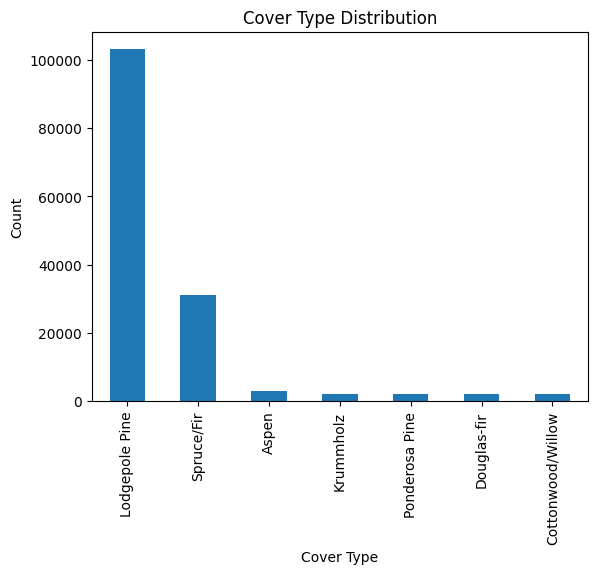

In [7]:
import matplotlib.pyplot as plt

df["Cover_Type"].value_counts().plot(kind="bar")
plt.title("Cover Type Distribution")
plt.xlabel("Cover Type")
plt.ylabel("Count")
plt.show()

In [8]:
print("\nDescribe:")
print(df.describe())


Describe:
           Elevation         Aspect          Slope  \
count  145890.000000  145890.000000  145890.000000   
mean     2874.458949     141.127418      11.925574   
std       210.801279     107.719296       6.319326   
min      1863.000000       0.000000       0.000000   
25%      2747.000000      54.000000       7.000000   
50%      2909.000000     108.000000      11.000000   
75%      3004.000000     217.000000      15.000000   
max      3849.000000     360.000000      61.000000   

       Horizontal_Distance_To_Hydrology  Vertical_Distance_To_Hydrology  \
count                     145890.000000                   145890.000000   
mean                         251.824738                       34.554322   
std                          192.473899                       41.215776   
min                            0.000000                     -146.000000   
25%                           95.000000                        7.000000   
50%                          212.000000             

In [9]:
selected_cols = [
    "Elevation",
    "Slope",
    "Horizontal_Distance_To_Hydrology",
    "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Horizontal_Distance_To_Fire_Points"
]
Q1 = df[selected_cols].quantile(0.25)
Q3 = df[selected_cols].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[selected_cols] < (Q1 - 1.5 * IQR)) |
            (df[selected_cols] > (Q3 + 1.5 * IQR)))

print(outliers.sum())

Elevation                             4448
Slope                                 3385
Horizontal_Distance_To_Hydrology      2473
Vertical_Distance_To_Hydrology        7123
Horizontal_Distance_To_Roadways          0
Horizontal_Distance_To_Fire_Points       0
dtype: int64


In [10]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df[selected_cols] = df[selected_cols].clip(lower, upper, axis=1)

In [11]:
print(df[selected_cols].skew())


Elevation                            -0.340370
Slope                                 0.621361
Horizontal_Distance_To_Hydrology      0.792349
Vertical_Distance_To_Hydrology        0.861265
Horizontal_Distance_To_Roadways      -0.058240
Horizontal_Distance_To_Fire_Points    0.365249
dtype: float64


In [12]:
# =========================
# 4. DERIVED FEATURES
# =========================
df["Distance_To_Hydrology"] = np.sqrt(df["Horizontal_Distance_To_Hydrology"]**2 + df["Vertical_Distance_To_Hydrology"]**2)
df["Hillshade_Mean"] = (df["Hillshade_9am"] + df["Hillshade_Noon"] + df["Hillshade_3pm"]) / 3
df["Hillshade_Range"] = df["Hillshade_3pm"] - df["Hillshade_9am"]
df["Near_Water"] = (df["Horizontal_Distance_To_Hydrology"] < 100).astype(int)
df["Fire_Risk"] = df["Horizontal_Distance_To_Fire_Points"] / (df["Slope"] + 1)

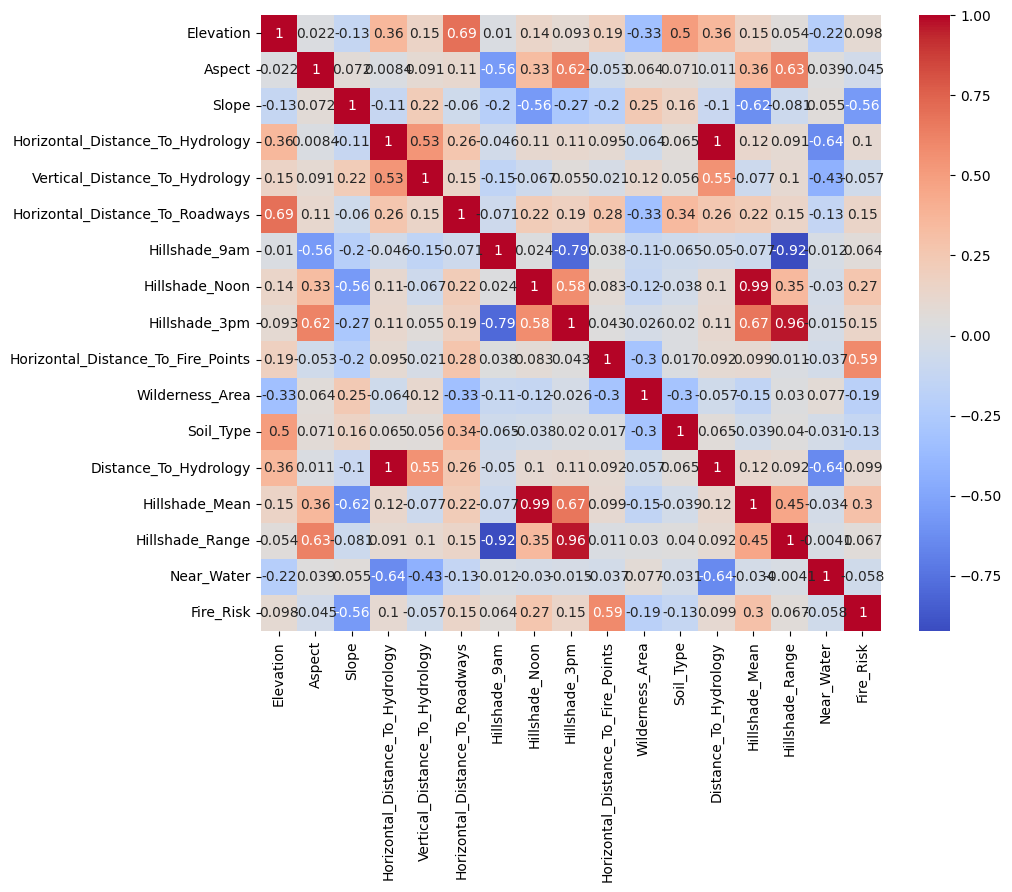

In [13]:
import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

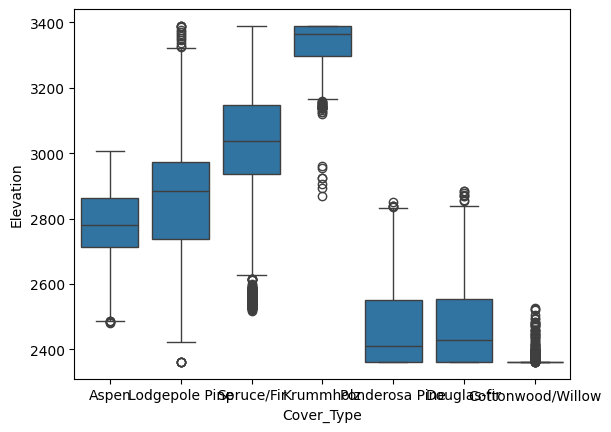

In [14]:
sns.boxplot(x="Cover_Type", y="Elevation", data=df)
plt.show()

Elevation                             0.259092
Horizontal_Distance_To_Roadways       0.135928
Horizontal_Distance_To_Fire_Points    0.110679
Soil_Type                             0.080259
Wilderness_Area                       0.066658
Fire_Risk                             0.046407
Vertical_Distance_To_Hydrology        0.043004
Distance_To_Hydrology                 0.042893
Horizontal_Distance_To_Hydrology      0.034681
Aspect                                0.031123
Hillshade_9am                         0.026344
Hillshade_Range                       0.026192
Hillshade_Mean                        0.025399
Hillshade_Noon                        0.024711
Hillshade_3pm                         0.024354
Slope                                 0.017811
Near_Water                            0.004466
dtype: float64
(145890, 18)


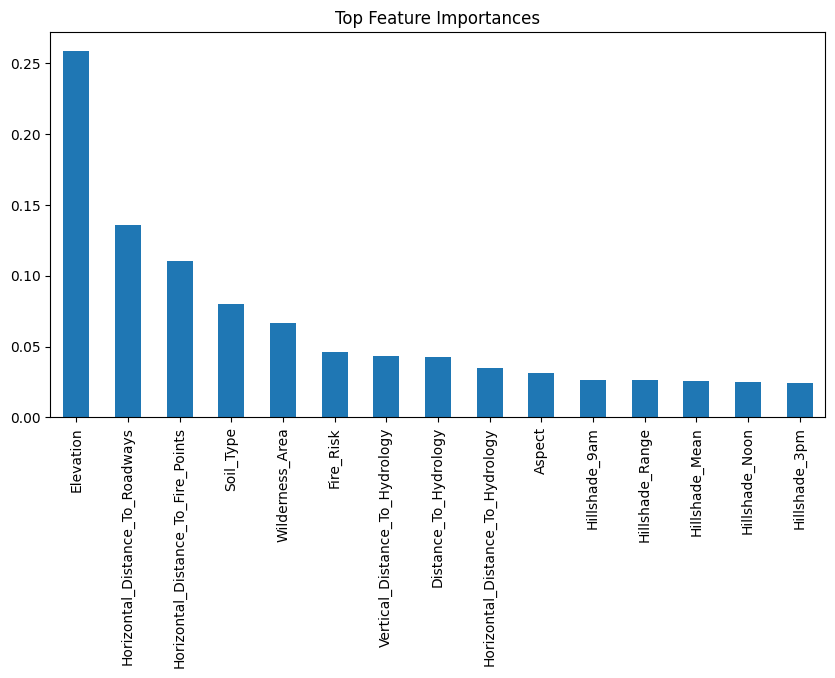

In [15]:
# Split features and target
X = df.drop("Cover_Type", axis=1)
y = df["Cover_Type"]

# Train model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Get feature importance
importance = pd.Series(rf.feature_importances_, index=X.columns)

# Sort
importance = importance.sort_values(ascending=False)

# Print top features
print(importance)
print(df.shape)
# Plot
importance.head(15).plot(kind='bar', figsize=(10,5))
plt.title("Top Feature Importances")
plt.show()

In [16]:
# keep only important features (> threshold)
selected_features = importance[importance > 0.01].index

df= df[selected_features.tolist() + ["Cover_Type"]]
print(df.shape)

(145890, 17)


In [17]:
# 5. DROP REDUNDANT FEATURES
corr_matrix = df.corr(numeric_only=True).abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
# find columns to drop
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]

print("Drop these columns:", to_drop)

# drop them
df = df.drop(columns=to_drop)
print(df.shape)

Drop these columns: ['Horizontal_Distance_To_Hydrology', 'Hillshade_Range', 'Hillshade_Noon', 'Hillshade_3pm']
(145890, 13)


In [18]:
le = LabelEncoder()

df["Cover_Type"] = le.fit_transform(df["Cover_Type"])

joblib.dump(le, "/Users/Pooja/Documents/target_encoder.pkl")

['/Users/Pooja/Documents/target_encoder.pkl']

In [19]:
# 6. FEATURES & TARGET
cat_cols = ["Wilderness_Area", "Soil_Type"]

num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols = [col for col in num_cols if col not in cat_cols + ["Cover_Type"]]

X = df[num_cols + cat_cols]
y = df["Cover_Type"]

In [20]:
# =========================
# 8. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [26]:
joblib.dump(X_train_final.columns.tolist(), "/Users/Pooja/Documents/capstone_projects/projects/features.pkl")

['/Users/Pooja/Documents/capstone_projects/projects/features.pkl']

In [25]:
# Encode ONLY on train
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_cat = encoder.fit_transform(X_train[cat_cols])
X_test_cat = encoder.transform(X_test[cat_cols])

# Convert to DataFrame
X_train_cat_df = pd.DataFrame(X_train_cat, columns=encoder.get_feature_names_out(cat_cols))
X_test_cat_df = pd.DataFrame(X_test_cat, columns=encoder.get_feature_names_out(cat_cols))

# Combine
X_train_final = pd.concat([X_train[num_cols].reset_index(drop=True), X_train_cat_df], axis=1)
X_test_final = pd.concat([X_test[num_cols].reset_index(drop=True), X_test_cat_df], axis=1)

joblib.dump(encoder, "/Users/Pooja/Documents/encoder.pkl")



['/Users/Pooja/Documents/encoder.pkl']

In [29]:
# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_final, y_train)

In [21]:
# DEFINE MODELS
# =========================
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="mlogloss")
}


# =========================
# TRAIN & EVALUATE
# =========================
results = []

for name, model in models.items():
    
    print(f"\n========== {name} ==========")
    
    # train
    model.fit(X_train, y_train)
    
    # predict
    y_pred = model.predict(X_test)
    
    # accuracy
    acc = accuracy_score(y_test, y_pred)
    
    print("Accuracy:", acc)
    
    # classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # confusion matrix
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    # store results
    results.append([name, acc])


# =========================
# FINAL COMPARISON TABLE
# =========================
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
print("\nModel Comparison:")
print(results_df.sort_values(by="Accuracy", ascending=False))


========== Decision Tree ==========
Accuracy: 0.9345739941051477

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       614
           1       0.92      0.87      0.89       432
           2       0.77      0.75      0.76       432
           3       0.91      0.93      0.92       432
           4       0.96      0.96      0.96     20614
           5       0.71      0.75      0.73       432
           6       0.89      0.88      0.88      6222

    accuracy                           0.93     29178
   macro avg       0.86      0.86      0.86     29178
weighted avg       0.93      0.93      0.93     29178


Confusion Matrix:
[[  524     0     2     0    75     9     4]
 [    0   377    21     0     0    34     0]
 [    8    13   322     0     9    80     0]
 [    1     0     0   403     6     0    22]
 [   62     0    12     5 19857     8   670]
 [   13    21    58     2    12   324     2]
 [   20     0     5    3

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.7810679278908766

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.03      0.05       614
           1       0.72      0.66      0.69       432
           2       0.38      0.07      0.12       432
           3       0.51      0.31      0.39       432
           4       0.80      0.97      0.87     20614
           5       0.53      0.27      0.36       432
           6       0.72      0.37      0.49      6222

    accuracy                           0.78     29178
   macro avg       0.64      0.38      0.42     29178
weighted avg       0.77      0.78      0.74     29178


Confusion Matrix:
[[   17     1     2     5   585     4     0]
 [    0   287     3     0   118    24     0]
 [    1    42    30     5   281    73     0]
 [    0     0     0   136    41     0   255]
 [    1     7     1    39 19920     2   644]
 [    1    64    44     4   203   116     0]
 [    0     0     0    77  3861     0  2284]]

========== KNN

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [23:19:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.933134553430667

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.85      0.86       614
           1       0.92      0.95      0.93       432
           2       0.79      0.84      0.81       432
           3       0.92      0.96      0.94       432
           4       0.95      0.97      0.96     20614
           5       0.82      0.80      0.81       432
           6       0.92      0.82      0.86      6222

    accuracy                           0.93     29178
   macro avg       0.88      0.88      0.88     29178
weighted avg       0.93      0.93      0.93     29178


Confusion Matrix:
[[  519     0    10     0    77     5     3]
 [    0   409    12     0     0    11     0]
 [    6    15   362     0     0    49     0]
 [    3     0     0   414     0     0    15]
 [   45     0    12     5 20093    10   449]
 [    3    22    59     0     3   345     0]
 [   15     0     3    30  1089     0  5085]]

Model Compariso

In [ ]:
# model
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_sm, y_train_sm)

# parameter grid
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# randomized search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,  # try 10 combinations
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

# fit
random_search.fit(X_train_sm, y_train_sm)

# best model
best_model = random_search.best_estimator_

print("Best Params:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
Best Score: 0.9912317967375036


In [ ]:
y_pred = best_model.predict(X_test_final)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test Accuracy: 0.9556172458701762
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       614
           1       0.94      0.94      0.94       432
           2       0.85      0.88      0.86       432
           3       0.92      0.98      0.95       432
           4       0.98      0.97      0.97     20614
           5       0.83      0.88      0.85       432
           6       0.92      0.92      0.92      6222

    accuracy                           0.96     29178
   macro avg       0.90      0.92      0.91     29178
weighted avg       0.96      0.96      0.96     29178



In [28]:
joblib.dump(best_model, "/Users/Pooja/Documents/tuned_model.pkl")


['/Users/Pooja/Documents/tuned_model.pkl']